In [190]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import pingouin as pg
from plt_rcs import *
import hds 
from statsmodels.stats.outliers_influence import variance_inflation_factor
plt.rc(group='figure', figsize = (4,4), dpi = 120)

In [191]:
sorted(os.listdir())

['sample_submission.csv',
 'submission.csv',
 'test.csv',
 'test1234.csv',
 'train.csv']

In [192]:
os.chdir('../data')

In [193]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [194]:
train.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Num ID
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,14860
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,47181
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,47182
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,47183
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,47184


In [195]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
 10  Num ID                   10000 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 859.5 KB


In [196]:
train.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
Num ID                     0
dtype: int64

In [197]:
train.describe().round(3)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Num ID
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.005,310.006,1538.776,39.987,107.951,0.034,40711.266
std,2886.896,2.000,1.484,179.284,9.969,63.654,0.181,14870.161
min,1.000,295.300,305.700,1168.000,3.800,0.000,0.000,14860.000
25%,2500.750,298.300,308.800,1423.000,33.200,53.000,0.000,23214.750
50%,5000.500,300.100,310.100,1503.000,40.100,108.000,0.000,48861.500
75%,7500.250,301.500,311.100,1612.000,46.800,162.000,0.000,53001.500
max,10000.000,304.500,313.800,2886.000,76.600,253.000,1.000,57174.000


In [198]:
train.describe(include=object)

/var/folders/sv/y5mjyypn4nj901cp1kktpq340000gn/T/ipykernel_58653/4098720718.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.describe(include=object)


,Product ID,Type,Failure Type
count,10000,10000,10000
unique,10000,3,6
top,M14860,L,No Failure
freq,1,6000,9652


In [199]:
train['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [200]:
train.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type', 'Num ID'],
      dtype='str')

In [201]:
train = train.drop(columns = ['UDI', 'Num ID']).set_index(keys = 'Product ID')
train.columns = ['Type', 'AirTmp', 'ProcessTmp', 'RotSpd', 'Torque', 'ToolWear', 'Target', 'FailureType']
train = train.drop(columns=['FailureType'])
train.head() 

,Type,AirTmp,ProcessTmp,RotSpd,Torque,ToolWear,Target
Product ID,,,,,,,
M14860,M,298.1,308.6,1551,42.8,0,0
L47181,L,298.2,308.7,1408,46.3,3,0
L47182,L,298.1,308.5,1498,49.4,5,0
L47183,L,298.2,308.6,1433,39.5,7,0
L47184,L,298.2,308.7,1408,40.0,9,0


In [202]:
train.columns

Index(['Type', 'AirTmp', 'ProcessTmp', 'RotSpd', 'Torque', 'ToolWear',
       'Target'],
      dtype='str')

In [188]:
test.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Failure Type'],
      dtype='str')

In [203]:
test = test.drop(columns=['UDI']).set_index('Product ID')

test.columns = [
    'Type',
    'AirTmp',
    'ProcessTmp',
    'RotSpd',
    'Torque',
    'ToolWear',
    'FailureType'
]

test.head()

,Type,AirTmp,ProcessTmp,RotSpd,Torque,ToolWear,FailureType
Product ID,,,,,,,
M24860,M,300.5,309.5,1451,47.8,93,No Failure
M24861,M,301.4,311.1,1697,35.6,160,No Failure
H39413,H,304.0,313.1,1612,33.7,100,No Failure
L57175,L,298.6,310.5,1276,55.2,91,No Failure
L57176,L,299.9,310.8,1400,46.2,219,No Failure


In [205]:
train['Target'].value_counts(normalize=True)

Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

### 원-핫 인코딩

In [206]:
train["Type"] = train["Type"].map({"L":0, "M":1, "H":2})

In [207]:
test["Type"] = test["Type"].map({"L":0, "M":1, "H":2})

### FailureType 컬럼 삭제

In [ ]:
import numpy as np
import pandas as pd

target_map = {
    "No Failure": 0,
    "Heat Dissipation Failure": 1,
    "Power Failure": 2,
    "Overstrain Failure": 3,
    "Tool Wear Failure": 4,
    "Random Failures": 5
}

train["Target_enc"] = train["Target"].map(target_map)

corr_result = (
    train.select_dtypes(include=np.number)
    .corr()["Target_enc"]
    .sort_values(ascending=False)
)

print(corr_result)

Type         NaN
AirTmp       NaN
ProcessTmp   NaN
RotSpd       NaN
Torque       NaN
ToolWear     NaN
Target       NaN
Target_enc   NaN
Name: Target_enc, dtype: float64


In [70]:
train.select_dtypes(include="number").corr()["Target_enc"].sort_values(ascending=False)

Type         NaN
AirTmp       NaN
ProcessTmp   NaN
RotSpd       NaN
Torque       NaN
ToolWear     NaN
Target       NaN
Target_enc   NaN
Name: Target_enc, dtype: float64

In [75]:
train["TempDiff"] = train["ProcessTmp"] - train["AirTmp"]
train["Power"] = train["Torque"] * train["RotSpd"]
train["WearRate"] = train["ToolWear"] / (train["RotSpd"] + 1)

In [66]:
train.select_dtypes(exclude=np.number).columns

Index(['FailureType'], dtype='str')

In [ ]:
train = train.drop(columns=["FailureType"])
# 해당 컬럼 삭제

In [69]:
train["Target_enc"] = train["Target"].map({
    "No Failure":0,
    "Heat Dissipation Failure":1,
    "Power Failure":2,
    "Overstrain Failure":3,
    "Tool Wear Failure":4,
    "Random Failures":5
})

In [36]:
num_cols = train.select_dtypes([int, float]).columns

In [37]:
num_cols

Index(['AirTmp', 'ProcessTmp', 'RotSpd', 'Torque', 'ToolWear', 'Target'], dtype='str')

In [ ]:
for i in range(len(num_cols) - 1):
    hds.plot.box_group(data=train, x='Target', y=num_cols[i], palette=['skyblue', 'orange'])
    plt.show()

### Target 범주형 비교

In [39]:
train.select_dtypes(object).columns

/var/folders/sv/y5mjyypn4nj901cp1kktpq340000gn/T/ipykernel_58653/1851502400.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.select_dtypes(object).columns


Index(['Type', 'FailureType'], dtype='str')

In [40]:
train['Type'].value_counts().sort_index()

Type
H    1003
L    6000
M    2997
Name: count, dtype: int64

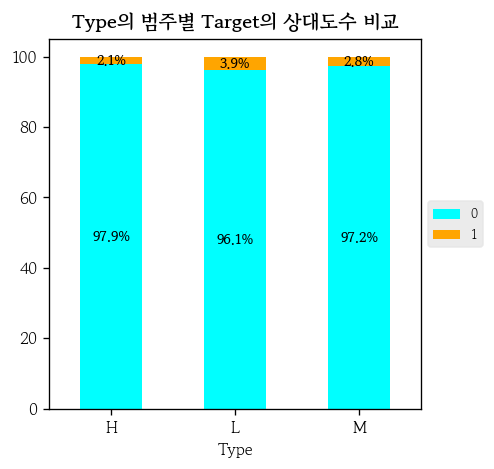

In [41]:
hds.plot.bar_stack_prop(data=train, x='Type', g='Target', palette=['aqua', 'orange'])

### 상관관계

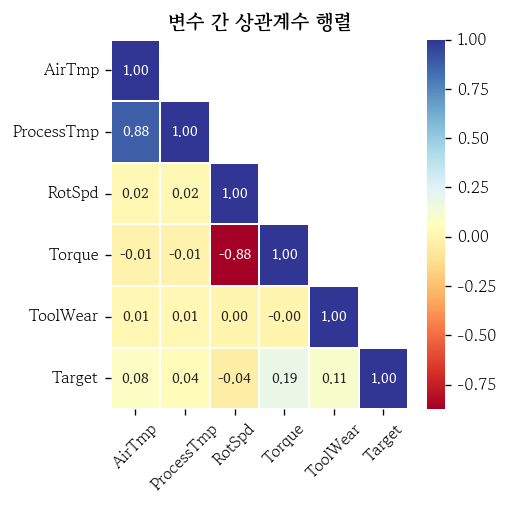

In [42]:
hds.plot.corr_heatmap(train)
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.show()

### 다중공선성 확인

In [45]:
X = train[['ProcessTmp', 'AirTmp']]

vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

      feature          VIF
0  ProcessTmp  87377.11919
1      AirTmp  87377.11919


In [48]:
train[['ProcessTmp','AirTmp','Target']].corr()

,ProcessTmp,AirTmp,Target
ProcessTmp,1.000000,0.876107,0.035946
AirTmp,0.876107,1.000000,0.082556
Target,0.035946,0.082556,1.000000


<Axes: xlabel='ProcessTmp', ylabel='Target'>

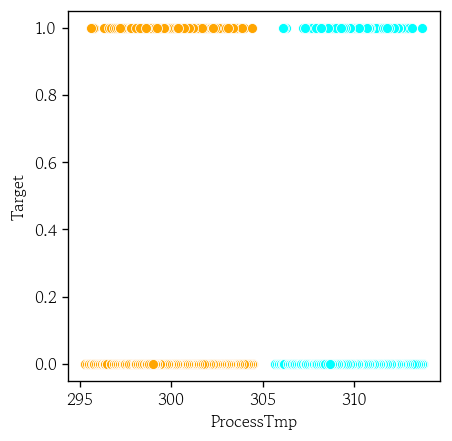

In [49]:
sns.scatterplot(x="ProcessTmp", y="Target", data=train)
sns.scatterplot(x="AirTmp", y="Target", data=train)

In [79]:
X = train.drop(columns=["Target"])
y = train["Target"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [80]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print(model.score(X_valid, y_valid))

0.991


In [82]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

pred = model.predict(X_valid)

print(confusion_matrix(y_valid, pred))
print(classification_report(y_valid, pred))
print("macro f1:", f1_score(y_valid, pred, average="macro"))
print("weighted f1:", f1_score(y_valid, pred, average="weighted"))

[[1929    3]
 [  15   53]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.95      0.78      0.85        68

    accuracy                           0.99      2000
   macro avg       0.97      0.89      0.93      2000
weighted avg       0.99      0.99      0.99      2000

macro f1: 0.9250973734145611
weighted f1: 0.9905784480175771


In [83]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(20))

Power         0.249599
RotSpd        0.181040
Torque        0.166318
TempDiff      0.115918
WearRate      0.115465
ToolWear      0.070809
AirTmp        0.044369
ProcessTmp    0.038055
Type          0.018428
Target_enc    0.000000
dtype: float64


In [84]:
train.columns

Index(['Type', 'AirTmp', 'ProcessTmp', 'RotSpd', 'Torque', 'ToolWear',
       'Target', 'Target_enc', 'TempDiff', 'Power', 'WearRate'],
      dtype='str')

In [85]:
train["TempDiff"] = train["ProcessTmp"] - train["AirTmp"]
train["Power"] = train["Torque"] * train["RotSpd"]
train["WearRate"] = train["ToolWear"] / (train["RotSpd"] + 1)
train["TempTorque"] = train["ProcessTmp"] * train["Torque"]
train["TempRatio"] = train["ProcessTmp"] / (train["AirTmp"] + 1e-6)

In [100]:
test["TempDiff"] = test["ProcessTmp"] - test["AirTmp"]
test["Power"] = test["Torque"] * test["RotSpeed"]
test["WearRate"] = test["ToolWear"] / (test["RotSpeed"] + 1)
test["TempTorque"] = test["ProcessTmp"] * test["Torque"]
test["TempRatio"] = test["ProcessTmp"] / (test["AirTmp"] + 1e-6)

In [99]:
test.columns

Index(['Type', 'AirTmp', 'ProcessTmp', 'RotSpeed', 'Torque', 'ToolWear',
       'FailureType', 'TempDiff'],
      dtype='str')

In [98]:
test = test.rename(columns={
    "UDI": "UDI",
    "Product ID": "ProductID",
    "Type": "Type",
    "Air temperature [K]": "AirTmp",
    "Process temperature [K]": "ProcessTmp",
    "Rotational speed [rpm]": "RotSpd",
    "Torque [Nm]": "Torque",
    "Tool wear [min]": "ToolWear",
    "Failure Type": "FailureType"
})

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# X, y 분리
X = train.drop(columns=["Target"])
y = train["Target"]

# 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 모델 학습
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 검증 점수
print(model.score(X_valid, y_valid))

0.99


In [103]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# feature / target 분리
X = train.drop(columns=["Target", "Target_enc", "FailureType"], errors="ignore")
y = train["Target"]

# train-valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 학습
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print(model.score(X_valid, y_valid))

# test도 같은 컬럼 구조로 맞추기
X_test = test.copy()
X_test = X_test.rename(columns={"RotSpeed": "RotSpd"})
X_test = X_test.drop(columns=["FailureType", "Target_enc", "Target"], errors="ignore")
X_test = X_test[X_train.columns]

# 예측
pred = model.predict(X_test)

0.9915


In [105]:
submission = pd.DataFrame({
    "UDI": test["UDI"],
    "Target": pred
})

submission.to_csv("submission.csv", index=False)

KeyError: 'UDI'

In [106]:
test.columns

Index(['Type', 'AirTmp', 'ProcessTmp', 'RotSpeed', 'Torque', 'ToolWear',
       'FailureType', 'TempDiff', 'Power', 'WearRate', 'TempTorque',
       'TempRatio'],
      dtype='str')

In [107]:
print(test.columns.tolist())

['Type', 'AirTmp', 'ProcessTmp', 'RotSpeed', 'Torque', 'ToolWear', 'FailureType', 'TempDiff', 'Power', 'WearRate', 'TempTorque', 'TempRatio']


In [111]:
sample = pd.read_csv("sample_submission.csv")

submission = sample.copy()
submission["Target"] = pred

submission.to_csv("test1234.csv", index=False)

In [109]:
submission.head()

,UDI,Target
0,10001,0
1,10002,0
2,10003,0
3,10004,0
4,10005,0
